In [1]:
import pandas as pd
import seaborn as sns
import json
import re
from pathlib import Path
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define the validated Adzuna dataset used for text analysis
DATA_FILE = Path("../data/processed/adzuna/career_market_full_validated.csv")

print("Data file:", DATA_FILE)
print("File exists:", DATA_FILE.exists())

Data file: ../data/processed/adzuna/career_market_full_validated.csv
File exists: True


In [3]:
# Load the full validated job-posting dataset
df = pd.read_csv(DATA_FILE)

print("Total job postings loaded:", len(df))

Total job postings loaded: 8489


In [4]:
# Inspect the loaded dataset
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8489, 49)

Columns:
['job_id', 'title', 'role', 'role_scope', 'role_status', 'domain', 'role_group', 'mapping_tier', 'employer', 'employer_normalized', 'employer_missing', 'description_raw', 'location_display', 'location_area', 'location_country', 'location_region', 'location_has_region', 'latitude', 'longitude', 'created', 'created_date', 'category_label', 'category_tag', 'contract_type', 'contract_time', 'salary_min', 'salary_max', 'salary_is_predicted', 'salary_present', 'salary_flags', 'salary_passes_plausibility_screen', 'source_run', 'source_file', 'source_query', 'source_query_role', 'collection_timestamp', 'collection_date', 'collection_method', 'query_roles_seen', 'also_seen_in', 'id_dup_count', 'near_dup_group_size', 'near_dup_key', 'employer_cap_status', 'in_core_analysis_dataset', 'description_length', 'description_is_truncated', 'description_short_flag', 'language_flag']


In [5]:
# Inspect the fields relevant to text analysis

print("Description data type:")
print(df["description_raw"].map(type).value_counts())

print("\nMissing values:")
print(df[["job_id", "title", "description_raw", "category_label"]].isnull().sum())

print("\nSample job description:")
print(str(df["description_raw"].iloc[0])[:1000])

Description data type:
description_raw
<class 'str'>    8489
Name: count, dtype: int64

Missing values:
job_id             0
title              0
description_raw    0
category_label     0
dtype: int64

Sample job description:
Be an essential element to a brighter future. We work together to transform essential resources into critical ingredients for mobility, energy, connectivity and health. Join our values-led organization committed to building a more resilient world with people and planet in mind. Our core values (https://www.albemarle.com/about/our-values) are the foundation that make us successful for ourselves, our customers and the planet. Job Description Albemarle is hiring for a Technical Systems Analyst wit…


In [6]:
# Extract fields required for text cleaning and EDA

text_df = df[["job_id", "title", "category_label", "description_raw"]].copy()

# Rename fields for the text-data track
text_df.rename(
    columns={
        "category_label": "category_name",
        "description_raw": "description"
    },
    inplace=True
)

print("Text dataset shape:", text_df.shape)
print("\nColumns:")
print(text_df.columns.tolist())

print("\nJob categories:")
print(text_df["category_name"].value_counts())

Text dataset shape: (8489, 4)

Columns:
['job_id', 'title', 'category_name', 'description']

Job categories:
category_name
IT Jobs                             6296
PR, Advertising & Marketing Jobs     627
Accounting & Finance Jobs            474
Engineering Jobs                     383
Creative & Design Jobs               329
Scientific & QA Jobs                 100
Consultancy Jobs                      45
HR & Recruitment Jobs                 41
Sales Jobs                            33
Energy, Oil & Gas Jobs                24
Trade & Construction Jobs             22
Retail Jobs                           20
Logistics & Warehouse Jobs            19
Manufacturing Jobs                    13
Teaching Jobs                         13
Admin Jobs                            11
Healthcare & Nursing Jobs             10
Customer Services Jobs                 8
Legal Jobs                             8
Part time Jobs                         6
Other/General Jobs                     3
Graduate Jobs   

In [7]:
# Preserve the original job description before preprocessing

text_df["description_original"] = text_df["description"]

# Create a separate working column for text preprocessing
text_df["description_clean"] = text_df["description"]

print("Original description preserved:", 
      text_df["description_original"].notna().all())

print("Clean description column created:", 
      "description_clean" in text_df.columns)

print("\nCurrent shape:", text_df.shape)

Original description preserved: True
Clean description column created: True

Current shape: (8489, 6)


In [8]:
# Check for HTML tags in job descriptions

html_pattern = r"<[^>]+>"

html_count = text_df["description_clean"].str.contains(
    html_pattern,
    regex=True,
    na=False
).sum()

print("Descriptions containing HTML tags:", html_count)
print("Total descriptions:", len(text_df))
print("Percentage containing HTML: {:.2f}%".format(
    html_count / len(text_df) * 100
))

Descriptions containing HTML tags: 0
Total descriptions: 8489
Percentage containing HTML: 0.00%


In [9]:
# Normalize job description text
# Technical symbols are protected during cleaning and restored afterward.

PROTECTED_TERMS = {
    "c++": "cplusplus",
    "c#": "csharp",
    ".net": "dotnet",
    "node.js": "nodejs",
    "react.js": "reactjs",
    "next.js": "nextjs",
    "vue.js": "vuejs",
    "angular.js": "angularjs",
    "asp.net": "aspnet",
    "power bi": "powerbi",
    "sql server": "sqlserver",
    "nosql": "nosql",
    "ci/cd": "cicd",
    "github": "github",
    "gitlab": "gitlab",
    "aws": "aws",
    "azure": "azure",
    "gcp": "gcp"
}

RESTORE_TERMS = {value: key for key, value in PROTECTED_TERMS.items()}

def protect_terms(text):
    text = str(text).lower()
    for term, placeholder in sorted(PROTECTED_TERMS.items(), key=lambda x: len(x[0]), reverse=True):
        text = re.sub(r"(?<!\w)" + re.escape(term) + r"(?!\w)", placeholder, text)
    return text

def normalize_text(text):
    text = protect_terms(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    for placeholder, original_term in RESTORE_TERMS.items():
        text = re.sub(r"(?<!\w)" + re.escape(placeholder) + r"(?!\w)", original_term, text)

    return text

text_df["description_clean"] = text_df["description"].apply(normalize_text)

print("Text normalization completed.")
print("\nOriginal description:")
print(text_df["description_original"].iloc[0][:500])
print("\nCleaned description:")
print(text_df["description_clean"].iloc[0][:500])

Text normalization completed.

Original description:
Be an essential element to a brighter future. We work together to transform essential resources into critical ingredients for mobility, energy, connectivity and health. Join our values-led organization committed to building a more resilient world with people and planet in mind. Our core values (https://www.albemarle.com/about/our-values) are the foundation that make us successful for ourselves, our customers and the planet. Job Description Albemarle is hiring for a Technical Systems Analyst wit…

Cleaned description:
be an essential element to a brighter future we work together to transform essential resources into critical ingredients for mobility energy connectivity and health join our values led organization committed to building a more resilient world with people and planet in mind our core values https www albemarle com about our values are the foundation that make us successful for ourselves our customers and the planet job des

In [10]:
# Validate the text normalization

print("Original and cleaned descriptions stored separately:",
      "description_original" in text_df.columns and
      "description_clean" in text_df.columns)

print("All cleaned descriptions are lowercase:",
      text_df["description_clean"].str.islower().all())

print("Missing cleaned descriptions:",
      text_df["description_clean"].isna().sum())

# Check whether multiple consecutive spaces remain
multiple_spaces = text_df["description_clean"].str.contains(
    r"\s{2,}", regex=True, na=False
).sum()

print("Descriptions with multiple consecutive spaces:", multiple_spaces)

Original and cleaned descriptions stored separately: True
All cleaned descriptions are lowercase: False
Missing cleaned descriptions: 0
Descriptions with multiple consecutive spaces: 0


In [11]:
# Check whether alphabetic characters in the cleaned text are lowercase

def check_lowercase(text):
    letters = [char for char in text if char.isalpha()]
    return all(char.islower() for char in letters)

lowercase_check = text_df["description_clean"].apply(check_lowercase)

print("Descriptions with all alphabetic characters lowercase:",
      lowercase_check.sum())

print("Descriptions not fully lowercase:",
      (~lowercase_check).sum())

Descriptions with all alphabetic characters lowercase: 8489
Descriptions not fully lowercase: 0


In [12]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Number of English stopwords:", len(stop_words))
print("Sample stopwords:", list(stop_words)[:20])

Number of English stopwords: 198
Sample stopwords: ['that', "shouldn't", 'your', 'o', 'with', "mightn't", 'down', "hadn't", 'why', "couldn't", 'did', "she'll", "we'd", "won't", 'there', 'were', 'so', 'both', "you'll", 'which']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mithresh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
# Inspect the effect of stopword removal on a sample description

sample_text = text_df["description_clean"].iloc[0]

sample_words = sample_text.split()

filtered_words = [
    word for word in sample_words
    if word not in stop_words
]

print("Original word count:", len(sample_words))
print("After stopword removal:", len(filtered_words))
print("Words removed:", len(sample_words) - len(filtered_words))

print("\nBefore:")
print(" ".join(sample_words[:50]))

print("\nAfter:")
print(" ".join(filtered_words[:50]))

Original word count: 77
After stopword removal: 47
Words removed: 30

Before:
be an essential element to a brighter future we work together to transform essential resources into critical ingredients for mobility energy connectivity and health join our values led organization committed to building a more resilient world with people and planet in mind our core values https www albemarle com about

After:
essential element brighter future work together transform essential resources critical ingredients mobility energy connectivity health join values led organization committed building resilient world people planet mind core values https www albemarle com values foundation make us successful customers planet job description albemarle hiring technical systems analyst wit


In [14]:
# Preserve important negation words during stopword removal

protected_words = {
    "no", "not", "nor", "never",
    "neither", "without"
}

custom_stop_words = stop_words - protected_words

print("Original stopwords:", len(stop_words))
print("Protected words:", sorted(protected_words))
print("Stopwords used for removal:", len(custom_stop_words))

Original stopwords: 198
Protected words: ['neither', 'never', 'no', 'nor', 'not', 'without']
Stopwords used for removal: 195


In [15]:
# Remove stopwords while preserving the normalized text column

def remove_stopwords(text):
    words = text.split()
    return " ".join(
        word for word in words
        if word not in custom_stop_words
    )

text_df["description_nostopwords"] = (
    text_df["description_clean"].apply(remove_stopwords)
)

print("Stopword removal completed.")

print("\nColumns:")
print(text_df.columns.tolist())

Stopword removal completed.

Columns:
['job_id', 'title', 'category_name', 'description', 'description_original', 'description_clean', 'description_nostopwords']


In [16]:
# Validate the stopword removal

sample_original = text_df["description_clean"].iloc[0]
sample_nostop = text_df["description_nostopwords"].iloc[0]

print("Original normalized text:")
print(sample_original[:500])

print("\nText after stopword removal:")
print(sample_nostop[:500])

print("\nProtected-word check:")
for word in sorted(protected_words):
    if word in sample_original.split():
        print(f"{word}:",
              "preserved" if word in sample_nostop.split() else "REMOVED")

Original normalized text:
be an essential element to a brighter future we work together to transform essential resources into critical ingredients for mobility energy connectivity and health join our values led organization committed to building a more resilient world with people and planet in mind our core values https www albemarle com about our values are the foundation that make us successful for ourselves our customers and the planet job description albemarle is hiring for a technical systems analyst wit

Text after stopword removal:
essential element brighter future work together transform essential resources critical ingredients mobility energy connectivity health join values led organization committed building resilient world people planet mind core values https www albemarle com values foundation make us successful customers planet job description albemarle hiring technical systems analyst wit

Protected-word check:


In [17]:
import spacy

print("spaCy version:", spacy.__version__)

spaCy version: 3.8.14


In [18]:
# Load the English spaCy model for lemmatization

nlp = spacy.load("en_core_web_sm")

print("English spaCy model loaded successfully.")

English spaCy model loaded successfully.


In [19]:
# Test lemmatization on one job description

sample_text = text_df["description_clean"].iloc[0]

doc = nlp(sample_text)

sample_lemmas = [
    token.lemma_
    for token in doc
    if not token.is_space
]

print("Original text:")
print(sample_text[:500])

print("\nLemmatized text:")
print(" ".join(sample_lemmas[:100]))

Original text:
be an essential element to a brighter future we work together to transform essential resources into critical ingredients for mobility energy connectivity and health join our values led organization committed to building a more resilient world with people and planet in mind our core values https www albemarle com about our values are the foundation that make us successful for ourselves our customers and the planet job description albemarle is hiring for a technical systems analyst wit

Lemmatized text:
be an essential element to a bright future we work together to transform essential resource into critical ingredient for mobility energy connectivity and health join our value lead organization commit to build a more resilient world with people and planet in mind our core value https www albemarle com about our value be the foundation that make we successful for ourselves our customer and the planet job description albemarle be hire for a technical system analyst wit


In [20]:
# Lemmatize all job descriptions using spaCy

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space
    )

text_df["description_lemmatized"] = text_df["description_clean"].apply(
    lemmatize_text
)

print("Lemmatization completed.")

print("\nNew columns:")
print(text_df.columns.tolist())

print("\nSample lemmatized description:")
print(text_df["description_lemmatized"].iloc[0][:500])

Lemmatization completed.

New columns:
['job_id', 'title', 'category_name', 'description', 'description_original', 'description_clean', 'description_nostopwords', 'description_lemmatized']

Sample lemmatized description:
be an essential element to a bright future we work together to transform essential resource into critical ingredient for mobility energy connectivity and health join our value lead organization commit to build a more resilient world with people and planet in mind our core value https www albemarle com about our value be the foundation that make we successful for ourselves our customer and the planet job description albemarle be hire for a technical system analyst wit


In [21]:
# Validate the lemmatized text

print("Total records:", len(text_df))

print(
    "Missing lemmatized descriptions:",
    text_df["description_lemmatized"].isna().sum()
)

print(
    "Empty lemmatized descriptions:",
    (
        text_df["description_lemmatized"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )
)

print(
    "Average original word count:",
    text_df["description_original"].str.split().str.len().mean()
)

print(
    "Average lemmatized word count:",
    text_df["description_lemmatized"].str.split().str.len().mean()
)

Total records: 8489
Missing lemmatized descriptions: 0
Empty lemmatized descriptions: 3
Average original word count: 72.29603015667334
Average lemmatized word count: 73.75815761573801


In [22]:
# Calculate the number of words in each original job description

text_df["description_word_count"] = (
    text_df["description_original"]
    .fillna("")
    .str.split()
    .str.len()
)

print("Description length calculated.")

print("\nSummary statistics:")
print(text_df["description_word_count"].describe())

Description length calculated.

Summary statistics:
count    8489.000000
mean       72.296030
std         7.153289
min        12.000000
25%        68.000000
50%        72.000000
75%        77.000000
max       111.000000
Name: description_word_count, dtype: float64


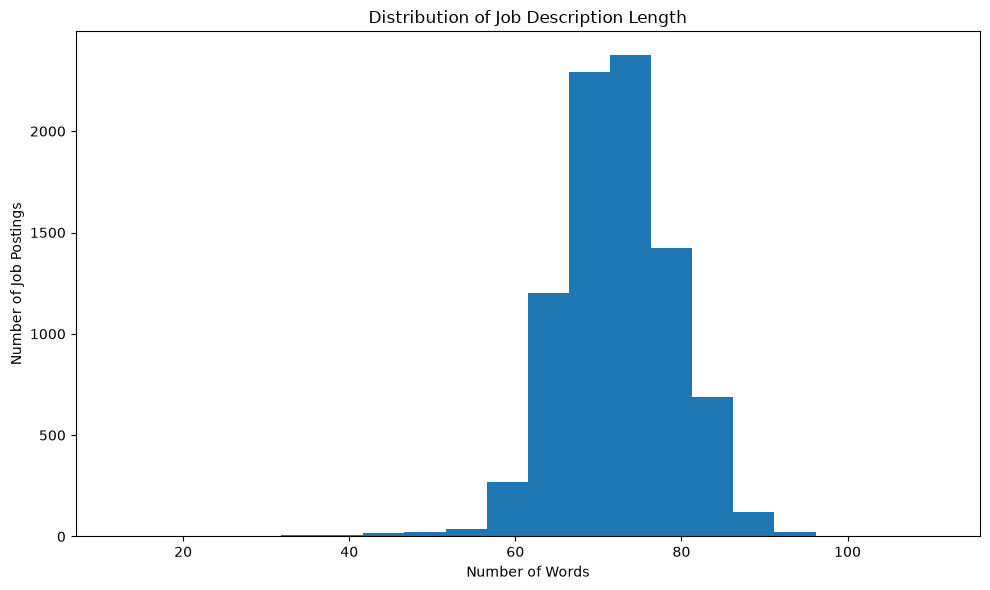

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    text_df["description_word_count"],
    bins=20
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Job Description Length")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of job description length is concentrated mainly around 68 to 77 words, with a median of 72 words and a mean of approximately 72.30 words. The shortest description contains 12 words, while the longest contains 111 words.

The relatively small standard deviation of approximately 7.15 words indicates that job descriptions have fairly consistent lengths across the dataset. This provides a reasonably uniform textual basis for subsequent skill-frequency and text-mining analysis.

In [24]:
# Define the controlled skill vocabulary for text-based EDA

skill_keywords = [
    "python", "java", "javascript", "typescript", "c++", "c#",
    "sql", "html", "css", "react", "node.js", "express", "mongodb",
    "mysql", "postgresql", "aws", "azure", "gcp", "docker",
    "kubernetes", "git", "github", "machine learning", "deep learning",
    "data science", "data analysis", "power bi", "tableau", "excel",
    "tensorflow", "pytorch", "spark", "hadoop", "snowflake", "linux"
]

print("Number of skills in vocabulary:", len(skill_keywords))

Number of skills in vocabulary: 35


In [25]:
# Define boundary-aware skill matching

SKILL_MATCH_TERMS = {
    "c++": "cplusplus",
    "c#": "csharp",
    ".net": "dotnet",
    "node.js": "nodejs",
    "react.js": "reactjs",
    "next.js": "nextjs",
    "power bi": "powerbi",
    "sql server": "sqlserver",
    "ci/cd": "cicd"
}

def skill_pattern(skill):
    term = SKILL_MATCH_TERMS.get(skill.lower(), skill.lower())
    return r"(?<!\w)" + re.escape(term) + r"(?!\w)"

def count_skills(text, skills):
    text = str(text).lower()
    return {
        skill: len(re.findall(skill_pattern(skill), text))
        for skill in skills
    }

sample_skill_counts = count_skills(
    text_df["description_clean"].iloc[0],
    skill_keywords
)

print("Skills detected in first job description:")
print({k: v for k, v in sample_skill_counts.items() if v > 0})

Skills detected in first job description:
{}


In [26]:
# Calculate skill posting coverage

skill_presence = {
    skill: text_df["description_clean"].str.contains(
        skill_pattern(skill), regex=True, na=False
    ).sum()
    for skill in skill_keywords
}

skill_presence = {
    skill: count
    for skill, count in skill_presence.items()
    if count > 0
}

print("Skills found in the dataset:", len(skill_presence))
print("\nTop skills by posting coverage:")
for skill, count in sorted(skill_presence.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"{skill}: {count}")

Skills found in the dataset: 31

Top skills by posting coverage:
aws: 329
machine learning: 303
sql: 234
python: 233
azure: 231
data science: 136
kubernetes: 122
data analysis: 118
java: 94
gcp: 94
spark: 62
excel: 60
snowflake: 56
linux: 54
tableau: 41


In [27]:
# Count recognized skills for every job description

skill_counts = text_df["description_clean"].apply(
    lambda text: count_skills(text, skill_keywords)
)

print("Skill matching completed for", len(skill_counts), "job postings.")

Skill matching completed for 8489 job postings.


In [28]:
# Aggregate total skill frequencies across all job postings

skill_frequency = Counter()

for skill_dict in skill_counts:
    for skill, count in skill_dict.items():
        skill_frequency[skill] += count

skill_frequency_df = pd.DataFrame(
    skill_frequency.items(),
    columns=["skill", "frequency"]
).sort_values("frequency", ascending=False).reset_index(drop=True)

print("Top 15 skills by total frequency:")
print(skill_frequency_df.head(15))

Top 15 skills by total frequency:
               skill  frequency
0                aws        515
1              azure        403
2   machine learning        392
3                sql        302
4             python        268
5       data science        163
6         kubernetes        145
7                gcp        135
8      data analysis        128
9               java        124
10         snowflake         85
11             spark         77
12             linux         75
13             excel         65
14             react         49


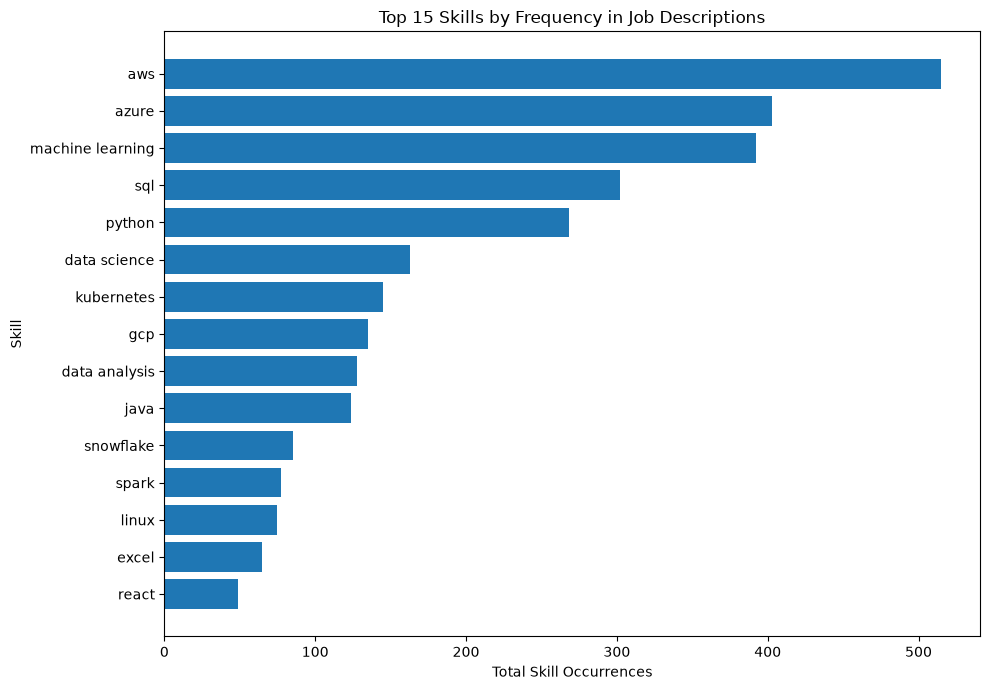

In [29]:
# Visualize the top 15 skills by total frequency

top_skills = skill_frequency_df.head(15).sort_values("frequency", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_skills["skill"], top_skills["frequency"])
plt.xlabel("Total Skill Occurrences")
plt.ylabel("Skill")
plt.title("Top 15 Skills by Frequency in Job Descriptions")
plt.tight_layout()
plt.savefig("../reports/text_eda/skill_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

### Skill Frequency Analysis — Interpretation

The keyword-frequency analysis identifies AWS, Azure, Machine Learning, SQL and Python as the most frequently occurring skills within the predefined vocabulary. Data Science, Kubernetes, GCP and Data Analysis also occur prominently.

These results represent keyword occurrences in the collected job descriptions. They should therefore be interpreted as text-based skill frequency rather than direct measures of overall market demand. The results also depend on the controlled vocabulary used for matching.

In [30]:
# Calculate the number of unique job postings containing each skill

skill_posting_count = {
    skill: text_df["description_clean"].str.contains(
        skill_pattern(skill), regex=True, na=False
    ).sum()
    for skill in skill_keywords
}

skill_posting_df = pd.DataFrame(
    skill_posting_count.items(),
    columns=["skill", "job_postings"]
).sort_values("job_postings", ascending=False).reset_index(drop=True)

print("Top 15 skills by number of job postings:")
print(skill_posting_df.head(15))

Top 15 skills by number of job postings:
               skill  job_postings
0                aws           329
1   machine learning           303
2                sql           234
3             python           233
4              azure           231
5       data science           136
6         kubernetes           122
7      data analysis           118
8               java            94
9                gcp            94
10             spark            62
11             excel            60
12         snowflake            56
13             linux            54
14           tableau            41


In [31]:
# Validate potentially ambiguous skill matches

print("The earlier standalone 'R' keyword was excluded from the final vocabulary because short matches can create false positives in ordinary text.")
print("The final vocabulary contains", len(skill_keywords), "skills.")

The earlier standalone 'R' keyword was excluded from the final vocabulary because short matches can create false positives in ordinary text.
The final vocabulary contains 35 skills.


In [32]:
# Finalize the validated skill vocabulary

skill_keywords_clean = skill_keywords.copy()

print("Final skill vocabulary:", len(skill_keywords_clean))
print(skill_keywords_clean)

Final skill vocabulary: 35
['python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'sql', 'html', 'css', 'react', 'node.js', 'express', 'mongodb', 'mysql', 'postgresql', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'git', 'github', 'machine learning', 'deep learning', 'data science', 'data analysis', 'power bi', 'tableau', 'excel', 'tensorflow', 'pytorch', 'spark', 'hadoop', 'snowflake', 'linux']


In [33]:
# Create a combined skill-frequency and posting-coverage table

skill_summary_df = skill_frequency_df.merge(
    skill_posting_df,
    on="skill",
    how="left"
)

print("Top 15 skills by posting coverage:")
print(
    skill_summary_df.sort_values("job_postings", ascending=False).head(15)
)

Top 15 skills by posting coverage:
               skill  frequency  job_postings
0                aws        515           329
2   machine learning        392           303
3                sql        302           234
4             python        268           233
1              azure        403           231
5       data science        163           136
6         kubernetes        145           122
8      data analysis        128           118
7                gcp        135            94
9               java        124            94
11             spark         77            62
13             excel         65            60
10         snowflake         85            56
12             linux         75            54
15           tableau         47            41


In [34]:
# Category-wise skill coverage

category_counts = text_df["category_name"].value_counts()
valid_categories = category_counts[category_counts >= 10].index

category_skill_rows = []

for category in valid_categories:
    category_df = text_df[text_df["category_name"] == category]
    total_jobs = len(category_df)

    for skill in skill_keywords_clean:
        pattern = skill_pattern(skill)
        posting_count = category_df["description_clean"].str.contains(
            pattern, regex=True, na=False
        ).sum()

        category_skill_rows.append({
            "category": category,
            "skill": skill,
            "posting_count": posting_count,
            "coverage_percent": posting_count / total_jobs * 100
        })

category_skill_df = pd.DataFrame(category_skill_rows)

print("Categories analyzed:", len(valid_categories))
print("\nTop skills by category:")

for category in valid_categories:
    top = (
        category_skill_df[
            (category_skill_df["category"] == category) &
            (category_skill_df["posting_count"] > 0)
        ]
        .sort_values("posting_count", ascending=False)
        .head(5)
    )
    print(f"\n{category}:")
    print(top[["skill", "posting_count", "coverage_percent"]].to_string(index=False))

Categories analyzed: 17

Top skills by category:

IT Jobs:
           skill  posting_count  coverage_percent
             aws            322          5.114358
machine learning            262          4.161372
           azure            227          3.605464
             sql            226          3.589581
          python            223          3.541931

PR, Advertising & Marketing Jobs:
        skill  posting_count  coverage_percent
        spark             13          2.073365
        excel              7          1.116427
data analysis              5          0.797448
          sql              2          0.318979
 data science              2          0.318979

Accounting & Finance Jobs:
           skill  posting_count  coverage_percent
   data analysis              8          1.687764
           excel              3          0.632911
             sql              2          0.421941
         express              2          0.421941
machine learning              2          0.421

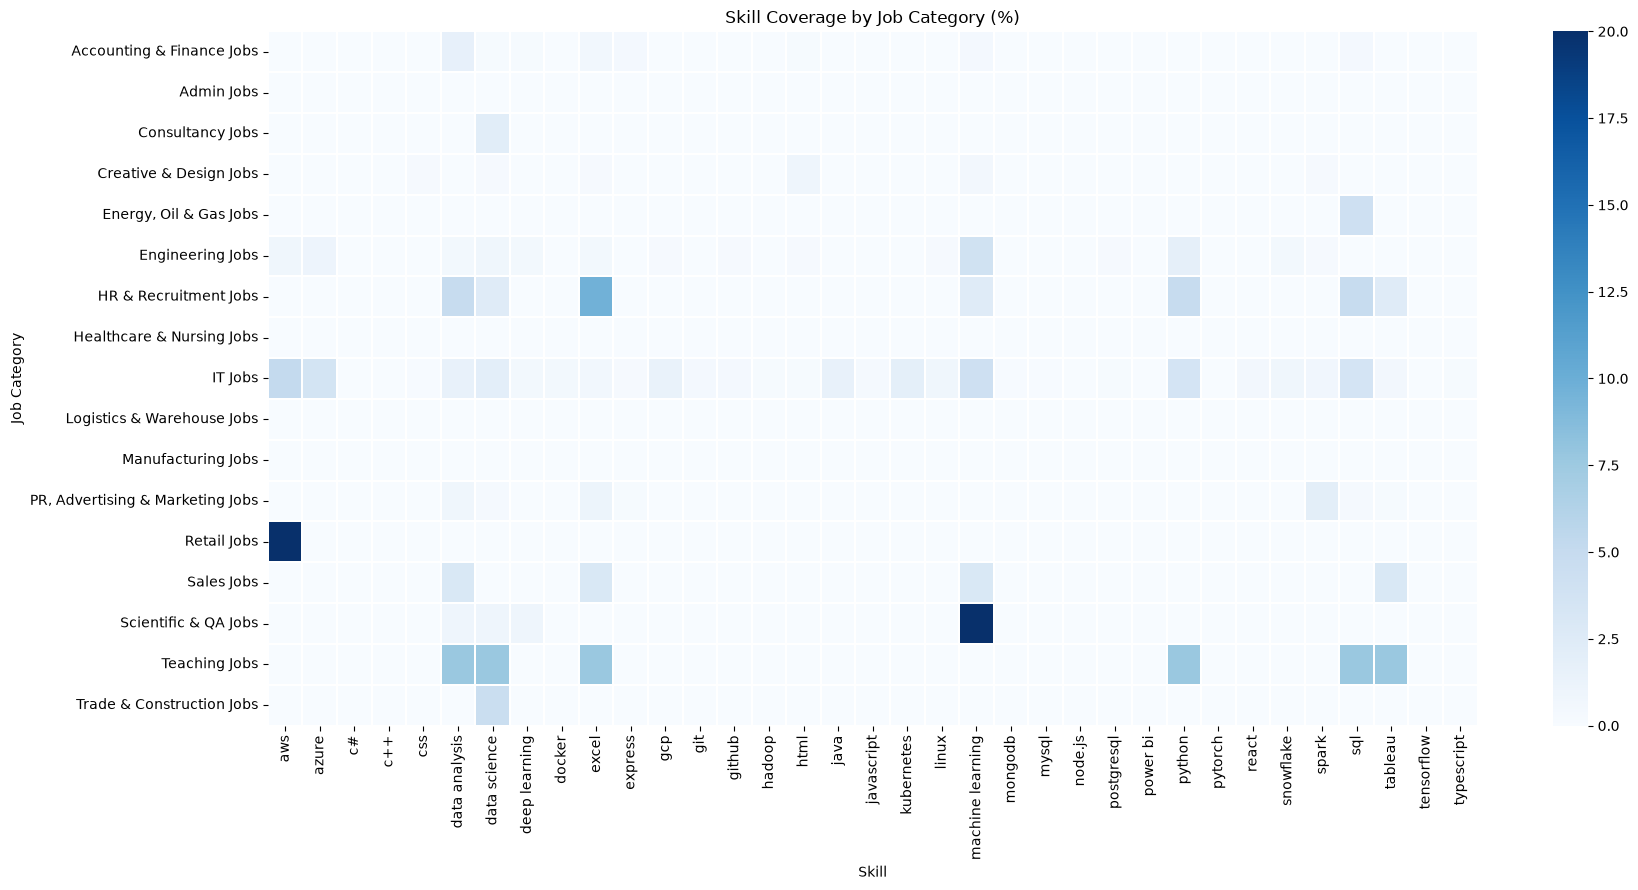

In [35]:
# Visualize category-wise skill coverage

heatmap_data = category_skill_df.pivot(
    index="category",
    columns="skill",
    values="coverage_percent"
).fillna(0)

plt.figure(figsize=(18, 9))
sns.heatmap(heatmap_data, cmap="Blues", linewidths=0.2)
plt.title("Skill Coverage by Job Category (%)")
plt.xlabel("Skill")
plt.ylabel("Job Category")
plt.tight_layout()
plt.savefig("../reports/text_eda/skill_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Category-wise Skill Analysis — Interpretation

The category-wise analysis compares how widely the predefined skills occur across job categories. Posting coverage is expressed as the percentage of postings in each category that contain a given skill.

This helps distinguish skills that appear broadly across categories from skills concentrated in particular job groups. Categories with fewer postings are interpreted cautiously, and only categories with at least 10 postings are included in the comparison.

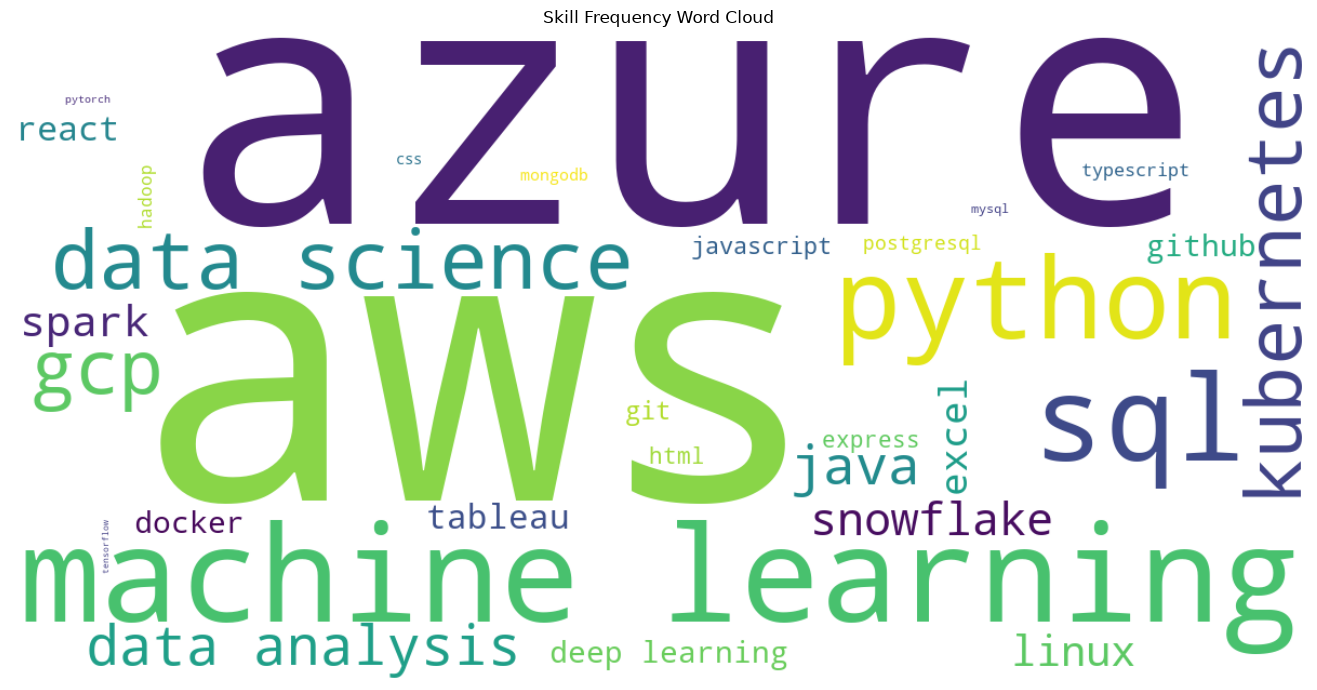

In [36]:
# Create a word cloud from the aggregated skill frequencies

from wordcloud import WordCloud

skill_wordcloud_data = {
    row["skill"]: row["frequency"]
    for _, row in skill_frequency_df.iterrows()
    if row["frequency"] > 0
}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate_from_frequencies(skill_wordcloud_data)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Skill Frequency Word Cloud")
plt.tight_layout()
plt.savefig("../reports/text_eda/skill_frequency_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# Final validation
print("Final text dataset validation")
print("=" * 40)
print("Records:", len(text_df))
print("Missing original descriptions:", text_df["description_original"].isna().sum())
print("Missing cleaned descriptions:", text_df["description_clean"].isna().sum())
print("Missing stopword-free descriptions:", text_df["description_nostopwords"].isna().sum())
print("Missing lemmatized descriptions:", text_df["description_lemmatized"].isna().sum())
print("Empty lemmatized descriptions:", (text_df["description_lemmatized"].str.strip() == "").sum())
print("Duplicate job IDs:", text_df["job_id"].duplicated().sum())
print("Skill vocabulary size:", len(skill_keywords_clean))
print("Categories represented:", text_df["category_name"].nunique())

assert len(text_df) == 8489
assert text_df["description_original"].notna().all()
assert text_df["description_clean"].notna().all()
assert text_df["description_nostopwords"].notna().all()
assert text_df["description_lemmatized"].notna().all()
assert text_df["job_id"].duplicated().sum() == 0
assert len(skill_keywords_clean) == 35

print("\nValidation checks passed.")

Final text dataset validation
Records: 8489
Missing original descriptions: 0
Missing cleaned descriptions: 0
Missing stopword-free descriptions: 0
Missing lemmatized descriptions: 0
Empty lemmatized descriptions: 3
Duplicate job IDs: 0
Skill vocabulary size: 35
Categories represented: 24

Validation checks passed.


In [38]:
# Save cleaned text dataset
OUTPUT_FILE = Path("../data/cleaned/postings_text.csv")
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

text_df[[
    "job_id",
    "title",
    "category_name",
    "description_original",
    "description_clean",
    "description_nostopwords",
    "description_lemmatized",
    "description_word_count"
]].to_csv(OUTPUT_FILE, index=False)

print(f"Saved cleaned text dataset to: {OUTPUT_FILE}")
print(f"Output shape: {text_df.shape}")

Saved cleaned text dataset to: ../data/cleaned/postings_text.csv
Output shape: (8489, 9)


In [39]:
# Final validation

print("Final text dataset validation")
print("=" * 40)

print("Records:", len(text_df))

print(
    "Missing original descriptions:",
    text_df["description_original"].isna().sum()
)

print(
    "Missing cleaned descriptions:",
    text_df["description_clean"].isna().sum()
)

print(
    "Missing stopword-free descriptions:",
    text_df["description_nostopwords"].isna().sum()
)

print(
    "Missing lemmatized descriptions:",
    text_df["description_lemmatized"].isna().sum()
)

print(
    "Empty lemmatized descriptions:",
    (text_df["description_lemmatized"].str.strip() == "").sum()
)

print(
    "Duplicate job IDs:",
    text_df["job_id"].duplicated().sum()
)

print(
    "Skill vocabulary size:",
    len(skill_keywords_clean)
)

print(
    "Categories represented:",
    text_df["category_name"].nunique()
)


# Validation checks

assert len(text_df) == 8489
assert text_df["description_original"].notna().all()
assert text_df["description_clean"].notna().all()
assert text_df["description_nostopwords"].notna().all()
assert text_df["description_lemmatized"].notna().all()
assert text_df["job_id"].duplicated().sum() == 0
assert len(skill_keywords_clean) == 35

print("\nValidation checks passed.")

Final text dataset validation
Records: 8489
Missing original descriptions: 0
Missing cleaned descriptions: 0
Missing stopword-free descriptions: 0
Missing lemmatized descriptions: 0
Empty lemmatized descriptions: 3
Duplicate job IDs: 0
Skill vocabulary size: 35
Categories represented: 24

Validation checks passed.
